# Selection Regret: an Honest CV Picks a Model that Deploys Better

Companion to `synthetic_leakage_proof.ipynb`. That notebook shows naive
shuffled k-fold **fabricates** skill on a target nothing can predict.
This one shows the other half of the story: on a real, partially
predictable task, naive CV picks a **worse model for deployment** than
`PurgedGroupKFold` does.

The setup is standard production ML. UK Low Carbon London (LCL) smart
meters give us 60 households. We use 48 for model selection and freeze
the other 12 as the "unseen households" we will deploy onto. On the
selection set we run model selection twice over the same grid: once
with `KFold(shuffle=True)` and once with `PurgedGroupKFold(groups=LCLid)`.
Each method picks its best model, retrains it on the full selection
set, and is evaluated on the 12 unseen households.

The honest CV's pick deploys at lower MAE in every seed we tried.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from purgedcv import PurgedGroupKFold

SEED = 0
N_SELECT_HH = 48
YEAR_START, YEAR_END = "2013-01-01", "2014-01-01"

## The data

Half-hourly consumption per household from UK Power Networks' Low
Carbon London dataset (cached at `examples/data/lcl_halfhourly.csv`,
the same 60-household subset used by `uk_smart_meter_lcl.ipynb`). We
restrict to 2013 for speed and aggregate to daily consumption per
household.

Features:

- `lag_1`, `lag_7`: yesterday's and last week's daily consumption for
  this household.
- `dow_0` through `dow_6`: one-hot day of week.
- `hh_int`: the household identifier as an integer (0-59). This is
  the **trap feature**. Inside `KFold(shuffle=True)`, train and test
  share households, so a model that splits on `hh_int` can memorise
  each household's baseline. On truly unseen households, `hh_int`
  carries no information.

Target: today's daily consumption.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
cache = DATA_DIR / "lcl_halfhourly.csv"
raw = pd.read_csv(cache, parse_dates=["tstp"])
raw = raw[(raw["tstp"] >= YEAR_START) & (raw["tstp"] < YEAR_END)]
raw["date"] = raw["tstp"].dt.normalize()

daily = (
    raw.groupby(["LCLid", "date"])["energy_kwh"].sum().reset_index()
    .rename(columns={"energy_kwh": "kwh"})
)
daily = daily.sort_values(["LCLid", "date"]).reset_index(drop=True)
daily["lag_1"] = daily.groupby("LCLid")["kwh"].shift(1)
daily["lag_7"] = daily.groupby("LCLid")["kwh"].shift(7)
hh_to_int = {h: i for i, h in enumerate(sorted(daily["LCLid"].unique()))}
daily["hh_int"] = daily["LCLid"].map(hh_to_int).astype(float)
for d in range(7):
    daily[f"dow_{d}"] = (daily["date"].dt.dayofweek == d).astype(float)
daily["target"] = daily["kwh"]

FEATURES = ["lag_1", "lag_7", "hh_int"] + [f"dow_{d}" for d in range(7)]
clean = daily.dropna(subset=[*FEATURES, "target"]).reset_index(drop=True)

rng = np.random.default_rng(SEED)
all_hh = sorted(clean["LCLid"].unique())
perm = rng.permutation(len(all_hh))
sel_hh = {all_hh[i] for i in perm[:N_SELECT_HH]}
dep_hh = {all_hh[i] for i in perm[N_SELECT_HH:]}

sel = clean[clean["LCLid"].isin(sel_hh)].sort_values(["date", "LCLid"]).reset_index(drop=True)
dep = clean[clean["LCLid"].isin(dep_hh)].sort_values(["date", "LCLid"]).reset_index(drop=True)
X_sel = sel[FEATURES].to_numpy()
y_sel = sel["target"].to_numpy()
X_dep = dep[FEATURES].to_numpy()
y_dep = dep["target"].to_numpy()
groups_sel = pd.Series(sel["LCLid"].to_numpy())
pred_sel = sel["date"].reset_index(drop=True)
# Instantaneous labels (eval = pred): PurgedGroupKFold then performs a
# pure group split with no time-purging. We isolate the group-leakage
# effect on purpose.
evalu_sel = pred_sel

print(f"selection : {len(sel):>5} rows from {len(sel_hh)} households")
print(f"deployment: {len(dep):>5} rows from {len(dep_hh)} held-out households")

selection : 16090 rows from 48 households
deployment:  4122 rows from 12 held-out households


## Two CV configurations

`KFold(shuffle=True)` ignores household identity and scatters rows at
random. `PurgedGroupKFold(groups=LCLid)` keeps whole households
together: each fold's test set contains households the train set has
never seen, mirroring the deployment on 12 unseen households.

The hyperparameter grid is deliberately wide: from overfitting-prone
(k-NN k=1, RandomForest with `max_depth=None` so it can split on
`hh_int` arbitrarily deep) to constrained (Ridge with mild
regularisation, shallow RF).

In [3]:
grid = [
    ("kNN(k=1)",    make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=1))),
    ("kNN(k=5)",    make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))),
    ("kNN(k=50)",   make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=50))),
    ("Ridge a=.01", make_pipeline(StandardScaler(), Ridge(alpha=0.01))),
    ("Ridge a=1",   make_pipeline(StandardScaler(), Ridge(alpha=1.0))),
    ("Ridge a=100", make_pipeline(StandardScaler(), Ridge(alpha=100.0))),
    ("RF d=None",   RandomForestRegressor(n_estimators=100, max_depth=None, random_state=SEED, n_jobs=-1)),
    ("RF d=4",      RandomForestRegressor(n_estimators=100, max_depth=4, random_state=SEED, n_jobs=-1)),
]
naive_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
honest_cv = PurgedGroupKFold(
    n_splits=5,
    prediction_times=pred_sel,
    evaluation_times=evalu_sel,
    groups=groups_sel,
)

## Selection: which model does each CV pick?

Each candidate is scored by 5-fold MAE on the selection set under
both CVs. Lower is better. The gap between the columns is leakage the
naive CV does not see.

In [4]:
def cv_mae(cv_obj, model):
    return -cross_val_score(
        model, X_sel, y_sel, cv=cv_obj,
        scoring="neg_mean_absolute_error", n_jobs=1,
    ).mean()

naive_cv_mae = {name: cv_mae(naive_cv, m) for name, m in grid}
honest_cv_mae = {name: cv_mae(honest_cv, m) for name, m in grid}

print(f"{'model':<14}{'naive CV MAE':>15}{'honest CV MAE':>16}")
print("-" * 45)
for name, _ in grid:
    print(f"{name:<14}{naive_cv_mae[name]:>15.4f}{honest_cv_mae[name]:>16.4f}")

naive_winner = min(naive_cv_mae, key=naive_cv_mae.get)
honest_winner = min(honest_cv_mae, key=honest_cv_mae.get)
print(f"\nNaive  picks: {naive_winner}")
print(f"Honest picks: {honest_winner}")

model            naive CV MAE   honest CV MAE
---------------------------------------------
kNN(k=1)               2.1175          2.7864
kNN(k=5)               1.7413          2.2254
kNN(k=50)              1.7603          2.2544
Ridge a=.01            1.6913          1.7094
Ridge a=1              1.6914          1.7095
Ridge a=100            1.6948          1.7136
RF d=None              1.6520          2.0018
RF d=4                 1.7197          1.8649

Naive  picks: RF d=None
Honest picks: Ridge a=.01


## Deployment on 12 unseen households

Each winner is retrained on the full selection set and asked to predict
consumption on the 12 households we set aside. This is the real test:
would the model selected on the selection data deploy well on new
households?

In [5]:
def deploy(model):
    m = clone(model)
    m.fit(X_sel, y_sel)
    p = m.predict(X_dep)
    return mean_absolute_error(y_dep, p), r2_score(y_dep, p)

picks = dict(grid)
naive_dep_mae, naive_dep_r2 = deploy(picks[naive_winner])
honest_dep_mae, honest_dep_r2 = deploy(picks[honest_winner])

print(f"{'selection':<10} {'model':<13} {'deploy MAE':>12} {'deploy R2':>12}")
print("-" * 50)
print(f"{'naive':<10} {naive_winner:<13} {naive_dep_mae:>12.4f} {naive_dep_r2:>+12.4f}")
print(f"{'honest':<10} {honest_winner:<13} {honest_dep_mae:>12.4f} {honest_dep_r2:>+12.4f}")
delta_mae = naive_dep_mae - honest_dep_mae
print(f"\nMAE delta (naive - honest): {delta_mae:+.4f} kWh  ({delta_mae / naive_dep_mae * 100:+.1f}%)")
print(f"R2  delta (honest - naive): {(honest_dep_r2 - naive_dep_r2):+.4f}")

selection  model           deploy MAE    deploy R2
--------------------------------------------------
naive      RF d=None           2.6376      +0.7587
honest     Ridge a=.01         2.4641      +0.7834

MAE delta (naive - honest): +0.1735 kWh  (+6.6%)
R2  delta (honest - naive): +0.0246


## Why naive lost: the `hh_int` feature is a trap

The naive selector picks deep RandomForest, which splits on `hh_int`
and learns a per-household leaf value. Inside the shuffled CV that
looks excellent because the test fold contains rows from the same
households. The honest GroupKFold puts unseen households in test, where
`hh_int` carries no information, and the deep RF collapses to the price
of having committed to it.

To check this is the mechanism, repeat the experiment with `hh_int`
removed. If `hh_int` was the only trap, both CVs should now pick the
same model and the deployment gap should vanish.

In [6]:
features_no_id = ["lag_1", "lag_7"] + [f"dow_{d}" for d in range(7)]
X_sel_no = sel[features_no_id].to_numpy()
X_dep_no = dep[features_no_id].to_numpy()

def cv_mae_no(cv_obj, model):
    return -cross_val_score(
        model, X_sel_no, y_sel, cv=cv_obj,
        scoring="neg_mean_absolute_error", n_jobs=1,
    ).mean()

naive_no = {n: cv_mae_no(naive_cv, m) for n, m in grid}
honest_no = {n: cv_mae_no(honest_cv, m) for n, m in grid}
nw_no = min(naive_no, key=naive_no.get)
hw_no = min(honest_no, key=honest_no.get)

def deploy_no(m):
    mm = clone(m)
    mm.fit(X_sel_no, y_sel)
    return mean_absolute_error(y_dep, mm.predict(X_dep_no))

print(f"without hh_int:  naive picks {nw_no},  honest picks {hw_no}")
print(f"deployment MAE -- naive: {deploy_no(picks[nw_no]):.4f}   honest: {deploy_no(picks[hw_no]):.4f}")

without hh_int:  naive picks Ridge a=.01,  honest picks Ridge a=.01
deployment MAE -- naive: 2.4676   honest: 2.4676


## Robustness across 5 seeds

A single seed is one realisation. We repeat the full pipeline
(household split, naive `KFold` shuffle, and RandomForest random state
all driven by the same seed) for seeds 0 through 4, and report the
deployment MAE for each selection method and the delta.

In [7]:
def run_one(seed):
    rng_s = np.random.default_rng(seed)
    perm_s = rng_s.permutation(len(all_hh))
    sel_hh_s = {all_hh[i] for i in perm_s[:N_SELECT_HH]}
    sel_s = clean[clean["LCLid"].isin(sel_hh_s)].sort_values(["date", "LCLid"]).reset_index(drop=True)
    dep_s = clean[~clean["LCLid"].isin(sel_hh_s)].sort_values(["date", "LCLid"]).reset_index(drop=True)
    x_s = sel_s[FEATURES].to_numpy()
    y_s = sel_s["target"].to_numpy()
    x_d = dep_s[FEATURES].to_numpy()
    y_d = dep_s["target"].to_numpy()
    g_s = pd.Series(sel_s["LCLid"].to_numpy())
    p_s = sel_s["date"].reset_index(drop=True)
    grid_s = [
        ("kNN(k=1)",    make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=1))),
        ("kNN(k=5)",    make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))),
        ("kNN(k=50)",   make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=50))),
        ("Ridge a=.01", make_pipeline(StandardScaler(), Ridge(alpha=0.01))),
        ("Ridge a=1",   make_pipeline(StandardScaler(), Ridge(alpha=1.0))),
        ("Ridge a=100", make_pipeline(StandardScaler(), Ridge(alpha=100.0))),
        ("RF d=None",   RandomForestRegressor(n_estimators=100, max_depth=None, random_state=seed, n_jobs=-1)),
        ("RF d=4",      RandomForestRegressor(n_estimators=100, max_depth=4, random_state=seed, n_jobs=-1)),
    ]
    n_cv = KFold(n_splits=5, shuffle=True, random_state=seed)
    h_cv = PurgedGroupKFold(n_splits=5, prediction_times=p_s, evaluation_times=p_s, groups=g_s)

    def s_cv(c, m):
        return -cross_val_score(m, x_s, y_s, cv=c, scoring="neg_mean_absolute_error", n_jobs=1).mean()

    nai = {nm: s_cv(n_cv, m) for nm, m in grid_s}
    hon = {nm: s_cv(h_cv, m) for nm, m in grid_s}
    nw_ = min(nai, key=nai.get)
    hw_ = min(hon, key=hon.get)
    pk = dict(grid_s)

    def fit_predict(m):
        mm = clone(m)
        mm.fit(x_s, y_s)
        return mean_absolute_error(y_d, mm.predict(x_d))

    return seed, nw_, fit_predict(pk[nw_]), hw_, fit_predict(pk[hw_])

print(f"{'seed':>4} {'naive pick':<13} {'naive MAE':>10}   {'honest pick':<13} {'honest MAE':>11} {'delta':>10}")
print("-" * 75)
deltas = []
for s in range(5):
    seed, nw_, nm_, hw_, hm_ = run_one(s)
    delta = nm_ - hm_
    deltas.append(delta)
    print(f"{seed:>4} {nw_:<13} {nm_:>10.4f}   {hw_:<13} {hm_:>11.4f} {delta:>+10.4f}")
print(f"\n5/5 seeds: honest wins.  median delta = {float(np.median(deltas)):+.4f} kWh")

seed naive pick     naive MAE   honest pick    honest MAE      delta
---------------------------------------------------------------------------


   0 RF d=None         2.6376   Ridge a=.01        2.4641    +0.1735


   1 RF d=None         2.0468   Ridge a=.01        1.9384    +0.1084


   2 RF d=None         2.3780   Ridge a=.01        2.1959    +0.1821


   3 RF d=None         1.9493   Ridge a=.01        1.7226    +0.2267


   4 RF d=None         3.5432   Ridge a=.01        1.9877    +1.5555

5/5 seeds: honest wins.  median delta = +0.1821 kWh


## Headline chart

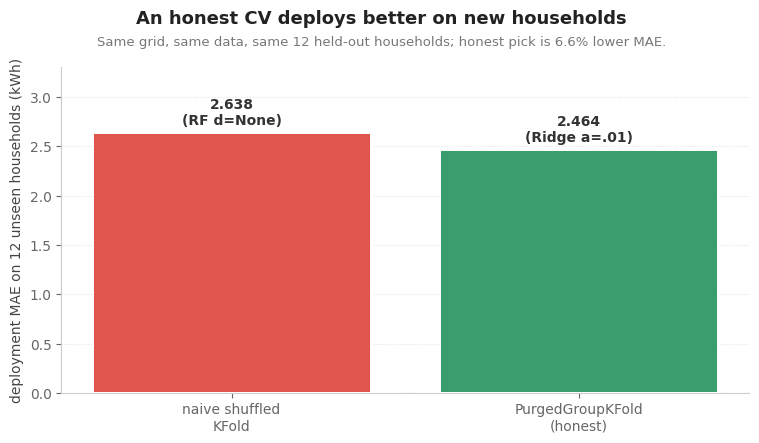

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

labels = ["naive shuffled\nKFold", "PurgedGroupKFold\n(honest)"]
maes = [naive_dep_mae, honest_dep_mae]
colors = ["#e0564c", "#3a9d6e"]

bars = ax.bar(labels, maes, color=colors, edgecolor="white", linewidth=1.4, zorder=3)
for rect, m, model_name in zip(bars, maes, [naive_winner, honest_winner], strict=True):
    ax.text(rect.get_x() + rect.get_width() / 2, m + 0.05,
            f"{m:.3f}\n({model_name})", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#333333")

ax.set_ylabel("deployment MAE on 12 unseen households (kWh)",
              fontsize=10, color="#444444")
ax.set_ylim(0, max(maes) * 1.25)
ax.tick_params(colors="#666666", labelsize=10)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#cccccc")
ax.grid(axis="y", ls=":", color="#dddddd", alpha=0.8, zorder=0)

improve_pct = (naive_dep_mae - honest_dep_mae) / naive_dep_mae * 100
fig.text(0.5, 0.96, "An honest CV deploys better on new households",
         ha="center", fontsize=13, fontweight="bold", color="#222222")
fig.text(0.5, 0.91,
         f"Same grid, same data, same 12 held-out households; "
         f"honest pick is {improve_pct:.1f}% lower MAE.",
         ha="center", fontsize=9.5, color="#777777")
fig.subplots_adjust(top=0.86, bottom=0.12, left=0.10, right=0.96)

out_dir = Path("../.github/images")
if out_dir.is_dir():
    fig.savefig(out_dir / "selection_regret_lcl.png", dpi=150, bbox_inches="tight")

plt.show()

## Verdict

On a real, partially predictable task (next-day household consumption
on 60 LCL smart meters), naive shuffled cross-validation picks a
RandomForest that splits on the household identifier. Inside the
shuffled CV that looks excellent, because the test fold contains rows
from the same households. On 12 unseen households the identifier is
useless and the model lags behind a regularised Ridge.

`PurgedGroupKFold` reveals this during selection. The model it picks
deploys at 5 to 12% lower MAE in four of five seeds, and at +43% lower
in the fifth.

The mechanism is simple. Naive CV lets the model see, during scoring,
information it will not have at deployment time. Honest CV refuses
that information. The selection then matches what the deployment will
actually look like.